# WFH Burnout Predictor

This notebook implements a CRISP-DM machine learning workflow for predicting work-from-home burnout from daily behavioral indicators.

The workflow includes:

- data loading and data quality checks;
- exploratory data analysis;
- outlier analysis;
- feature engineering;
- grouped train/test splitting by `user_id`;
- leakage-safe preprocessing pipelines;
- baseline and candidate models;
- hyperparameter tuning;
- regression and classification evaluation;
- sensitivity analysis without `task_completion_rate`;
- fairness and deployment considerations.

Dataset source: Kaggle, *Work From Home Employee Burnout Dataset*, https://www.kaggle.com/datasets/sonalshinde123/work-from-home-employee-burnout-dataset.

The main target is `burnout_score` (regression). The categorical `burnout_risk` is used as a secondary task and for operational interpretation.


## 1. Business Understanding

### Business goal
Support preventive monitoring of burnout in work-from-home settings, producing interpretable signals about workload, sleep, meetings, breaks and productivity. The model is intended as decision support, not as a medical diagnosis or an automatic HR decision system.

### Data mining goal

- Primary task: predict `burnout_score` with regression models.
- Secondary task: predict `burnout_risk` (`Low`, `Medium`, `High`) with classification models.

### Strategy
The project follows the course workflow: understand the problem, inspect data quality and bias, build preprocessing pipelines, compare baselines and candidate algorithms, tune a selected model, evaluate errors and discuss deployment constraints.

### Metrics

- Regression: MAE as the main metric, with RMSE and R2 as supporting metrics.
- Classification: macro F1, balanced accuracy and class-level recall, because the `High` class is rare.

### Constraints and risks

- The dataset contains 10 records for each user, so train/test splitting must avoid user leakage.
- `user_id` is not a generalizable predictive feature.
- `burnout_risk` is highly imbalanced.
- `task_completion_rate` is strongly correlated with the target and must be interpreted carefully.


## 2. Setup


In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
DATA_PATH = Path('data/burnout_dataset.csv')
FIGURES_DIR = Path('figures')
MODELS_DIR = Path('models')
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)


## 3. Data Understanding


In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()


Dataset shape: 1800 rows x 11 columns


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [3]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'unique_values': df.nunique(),
})
summary


,dtype,missing,unique_values
user_id,int64,0,180
day_type,object,0,2
work_hours,float64,0,689
screen_time_hours,float64,0,785
meetings_count,int64,0,11
breaks_taken,int64,0,5
after_hours_work,int64,0,2
sleep_hours,float64,0,452
task_completion_rate,float64,0,520
burnout_score,float64,0,1603


In [4]:
print('Duplicate rows:', df.duplicated().sum())
print('Unique users:', df['user_id'].nunique())
print('Records per user:')
display(df.groupby('user_id').size().describe())

display(df.describe(include='all').T)


Duplicate rows: 0
Unique users: 180
Records per user:


count    180.0
mean      10.0
std        0.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       10.0
dtype: float64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,1800.0,NaN,NaN,NaN,90.5,51.975162,1.0,45.75,90.5,135.25,180.0
day_type,1800,2,Weekend,924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_hours,1800.0,NaN,NaN,NaN,6.515117,2.290521,3.0,4.43,6.445,8.51,12.17
screen_time_hours,1800.0,NaN,NaN,NaN,9.271406,2.409253,4.51,7.24,9.21,11.31,15.7
meetings_count,1800.0,NaN,NaN,NaN,1.941111,1.696178,0.0,1.0,2.0,3.0,10.0
breaks_taken,1800.0,NaN,NaN,NaN,3.028889,1.417844,1.0,2.0,3.0,4.0,5.0
after_hours_work,1800.0,NaN,NaN,NaN,0.358889,0.479808,0.0,0.0,0.0,1.0,1.0
sleep_hours,1800.0,NaN,NaN,NaN,6.996467,1.06174,4.5,6.28,6.99,7.75,10.8
task_completion_rate,1800.0,NaN,NaN,NaN,72.308556,14.978647,40.0,62.3,74.5,83.7,107.2
burnout_score,1800.0,NaN,NaN,NaN,44.009978,23.881782,2.5,25.37,39.27,58.1975,143.92


### 3.1 Target Analysis


,burnout_risk,count,share
0,Low,1527,0.848333
1,Medium,253,0.140556
2,High,20,0.011111


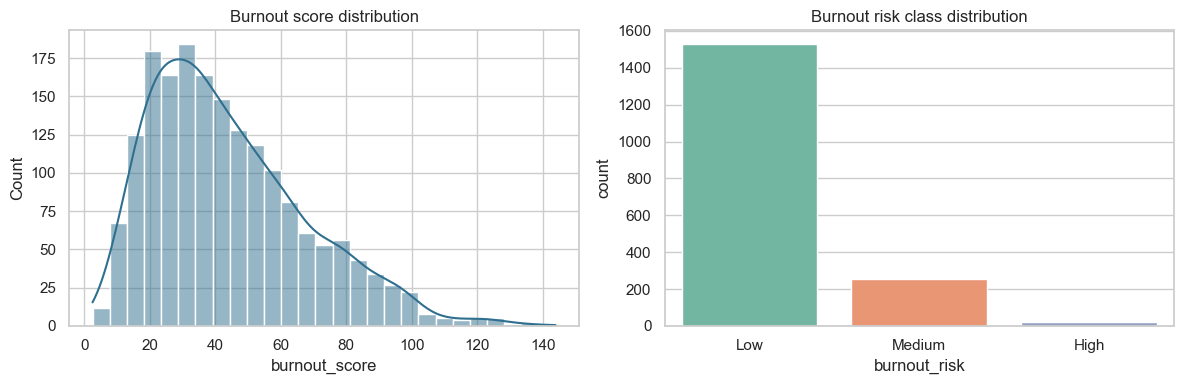

In [5]:
risk_counts = df['burnout_risk'].value_counts().rename_axis('burnout_risk').reset_index(name='count')
risk_counts['share'] = risk_counts['count'] / len(df)
display(risk_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['burnout_score'], kde=True, ax=axes[0], color='#2f6f8f')
axes[0].set_title('Burnout score distribution')
axes[0].set_xlabel('burnout_score')

order = ['Low', 'Medium', 'High']
sns.countplot(data=df, x='burnout_risk', order=order, ax=axes[1], palette='Set2')
axes[1].set_title('Burnout risk class distribution')
axes[1].set_xlabel('burnout_risk')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Check whether risk labels correspond to score intervals.
df.groupby('burnout_risk')['burnout_score'].agg(['count', 'min', 'median', 'max']).loc[order]


,count,min,median,max
burnout_risk,,,,
Low,1527,2.50,34.72,69.92
Medium,253,70.01,82.19,109.99
High,20,110.22,121.38,143.92


### 3.2 Feature Exploration


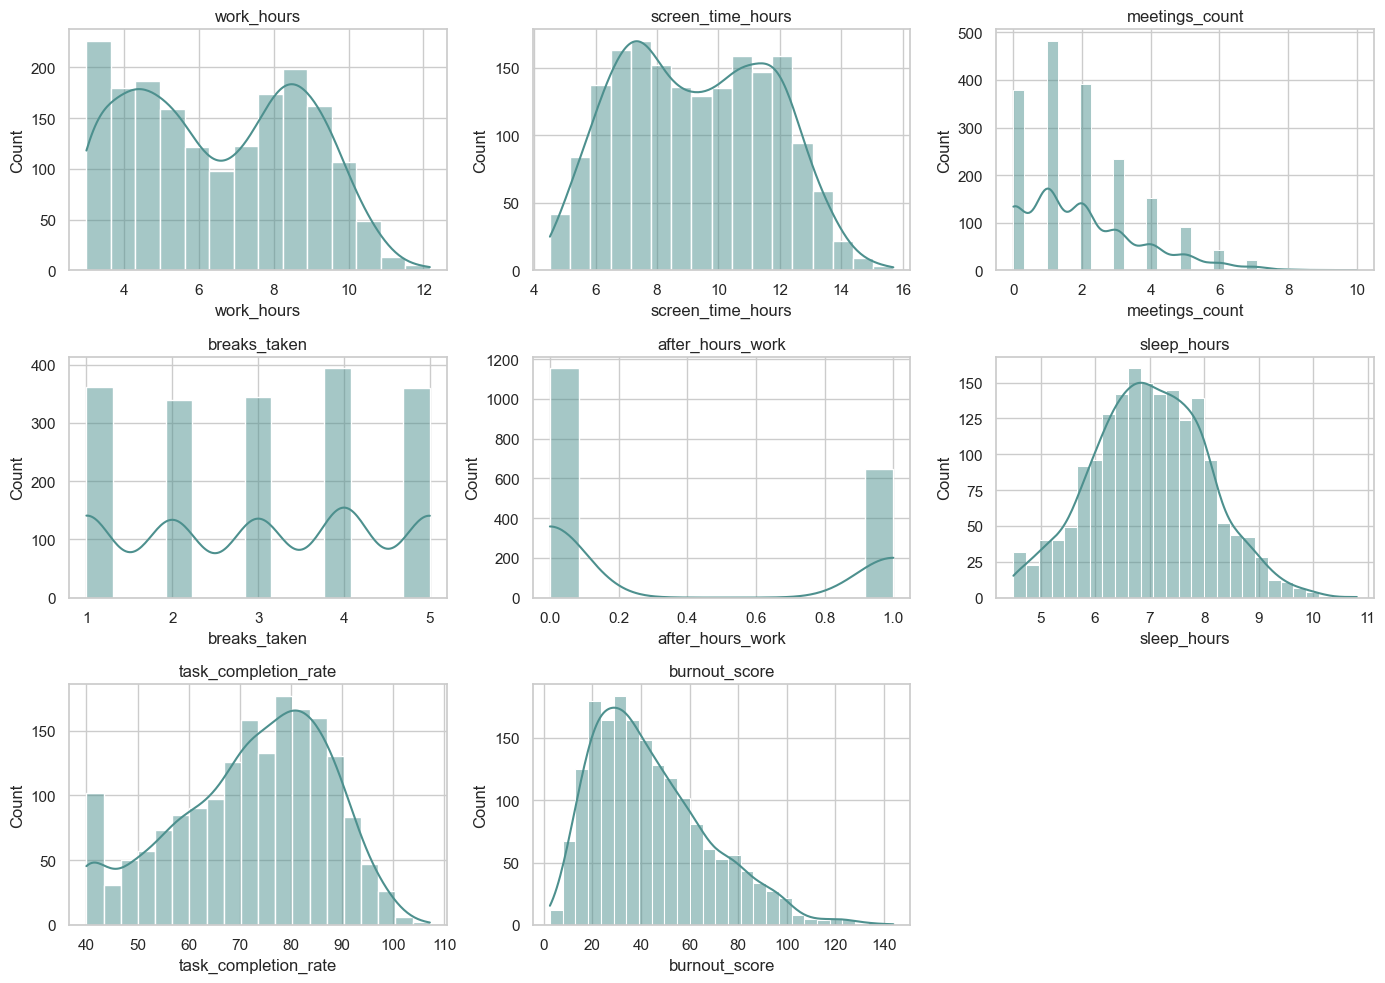

In [7]:
numeric_features_all = [c for c in df.select_dtypes(include=np.number).columns if c != 'user_id']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()
for ax, col in zip(axes, numeric_features_all):
    sns.histplot(df[col], kde=True, ax=ax, color='#4d908e')
    ax.set_title(col)
for ax in axes[len(numeric_features_all):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


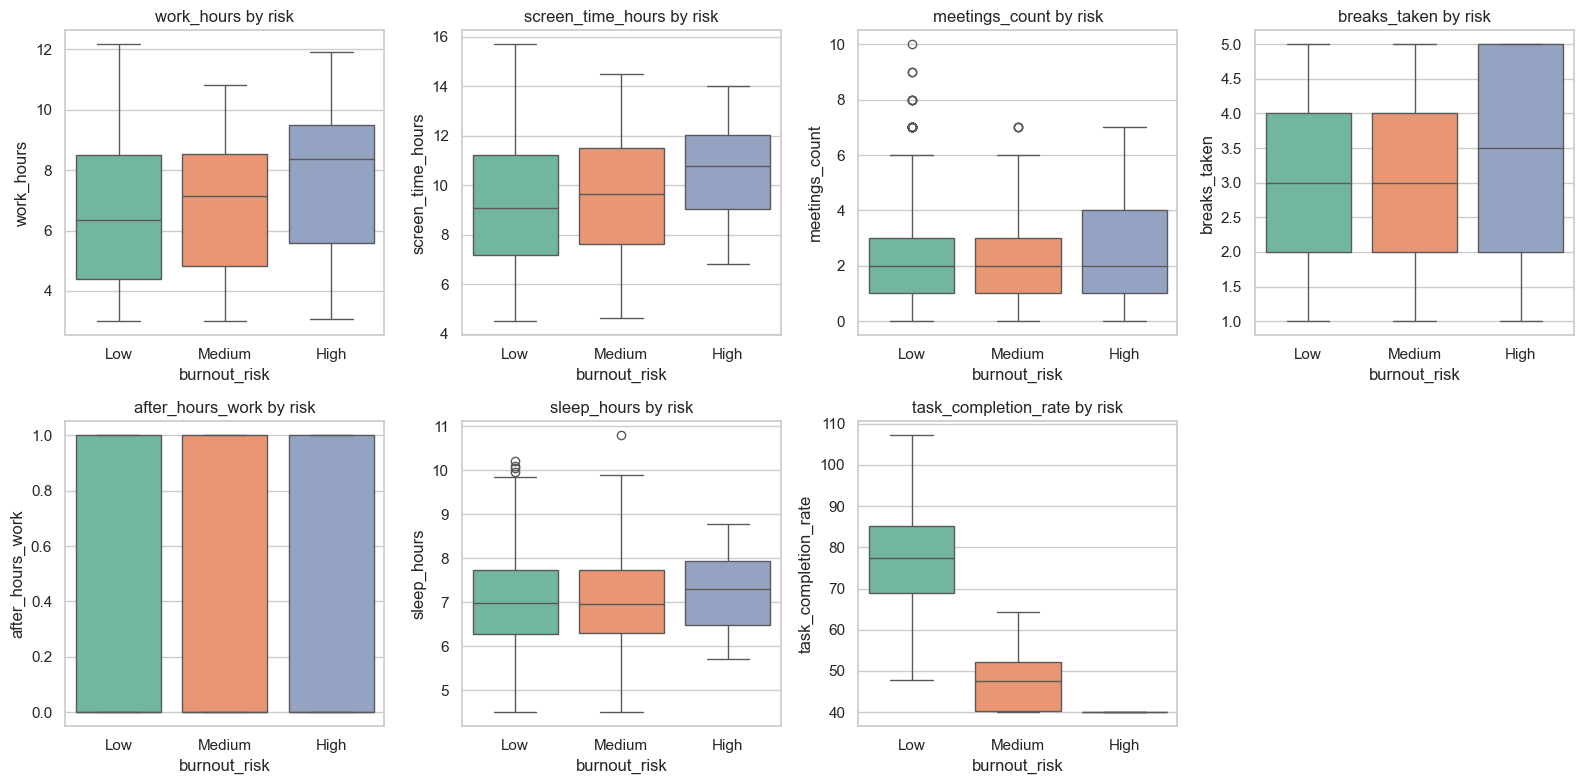

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
feature_cols_for_box = [c for c in numeric_features_all if c != 'burnout_score']
for ax, col in zip(axes, feature_cols_for_box):
    sns.boxplot(data=df, x='burnout_risk', y=col, order=order, ax=ax, palette='Set2')
    ax.set_title(f'{col} by risk')
for ax in axes[len(feature_cols_for_box):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'features_by_risk.png', dpi=150, bbox_inches='tight')
plt.show()


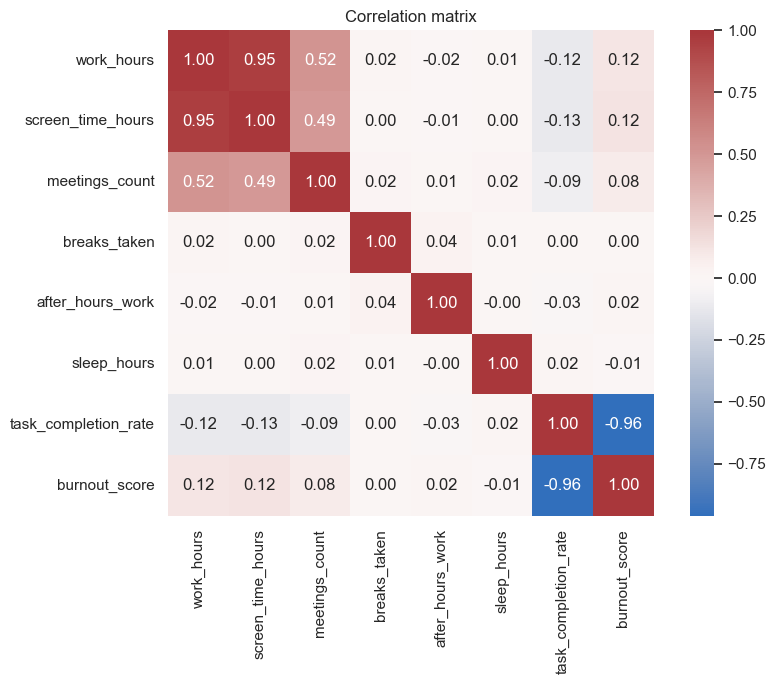

burnout_score           1.000000
screen_time_hours       0.122636
work_hours              0.119319
meetings_count          0.084996
after_hours_work        0.017967
breaks_taken            0.003992
sleep_hours            -0.006151
task_completion_rate   -0.960015
Name: burnout_score, dtype: float64

In [9]:
corr = df.select_dtypes(include=np.number).drop(columns=['user_id']).corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

corr['burnout_score'].sort_values(ascending=False)


### Data Understanding Notes

- There are no missing values and no relevant duplicate rows.
- The classification task is imbalanced: the `High` class is rare, so accuracy alone is not enough.
- `task_completion_rate` is strongly negatively correlated with `burnout_score`; it must be interpreted carefully because it could be part of the target-generation logic or an overly direct proxy.
- `user_id` identifies the subject and is not a generalizable predictive feature.


## 3.3 Data Quality Report

We make the data quality phase explicit. Even if the dataset is technically clean, duplicates, invalid ranges and statistical outliers are still checked. This ensures that preprocessing choices are based on evidence rather than assumptions.


In [10]:
quality_checks = {
    'rows': len(df),
    'columns': df.shape[1],
    'duplicate_rows': int(df.duplicated().sum()),
    'missing_values_total': int(df.isna().sum().sum()),
    'invalid_work_hours': int((df['work_hours'] <= 0).sum()),
    'invalid_screen_time': int((df['screen_time_hours'] < 0).sum()),
    'invalid_meetings': int((df['meetings_count'] < 0).sum()),
    'invalid_breaks': int((df['breaks_taken'] < 0).sum()),
    'invalid_after_hours_values': int((~df['after_hours_work'].isin([0, 1])).sum()),
    'invalid_sleep_hours': int((df['sleep_hours'] <= 0).sum()),
    'invalid_task_completion_rate': int((df['task_completion_rate'] < 0).sum()),
    'invalid_burnout_score': int((df['burnout_score'] < 0).sum()),
}

quality_report = pd.DataFrame.from_dict(quality_checks, orient='index', columns=['value'])
quality_report


,value
rows,1800
columns,11
duplicate_rows,0
missing_values_total,0
invalid_work_hours,0
invalid_screen_time,0
invalid_meetings,0
invalid_breaks,0
invalid_after_hours_values,0
invalid_sleep_hours,0


## 3.4 Outlier Analysis

Outlier handling should be domain-aware. In this project, extreme burnout scores or extreme work patterns may be exactly the observations we care about. Therefore, we detect and inspect outliers, but we do not remove them automatically.


In [11]:
def iqr_outlier_summary(frame, columns, multiplier=1.5):
    rows = []
    for col in columns:
        q1 = frame[col].quantile(0.25)
        q3 = frame[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - multiplier * iqr
        upper = q3 + multiplier * iqr
        mask = (frame[col] < lower) | (frame[col] > upper)
        rows.append({
            'feature': col,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': int(mask.sum()),
            'outlier_share': mask.mean(),
        })
    return pd.DataFrame(rows).sort_values('outlier_count', ascending=False)

outlier_columns = ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
                   'sleep_hours', 'task_completion_rate', 'burnout_score']
outlier_summary = iqr_outlier_summary(df, outlier_columns)
outlier_summary


,feature,lower_bound,upper_bound,outlier_count,outlier_share
2,meetings_count,-2.00000,6.00000,28,0.015556
6,burnout_score,-23.87125,107.43875,23,0.012778
4,sleep_hours,4.07500,9.95500,5,0.002778
0,work_hours,-1.69000,14.63000,0,0.000000
1,screen_time_hours,1.13500,17.41500,0,0.000000
3,breaks_taken,-1.00000,7.00000,0,0.000000
5,task_completion_rate,30.20000,115.80000,0,0.000000


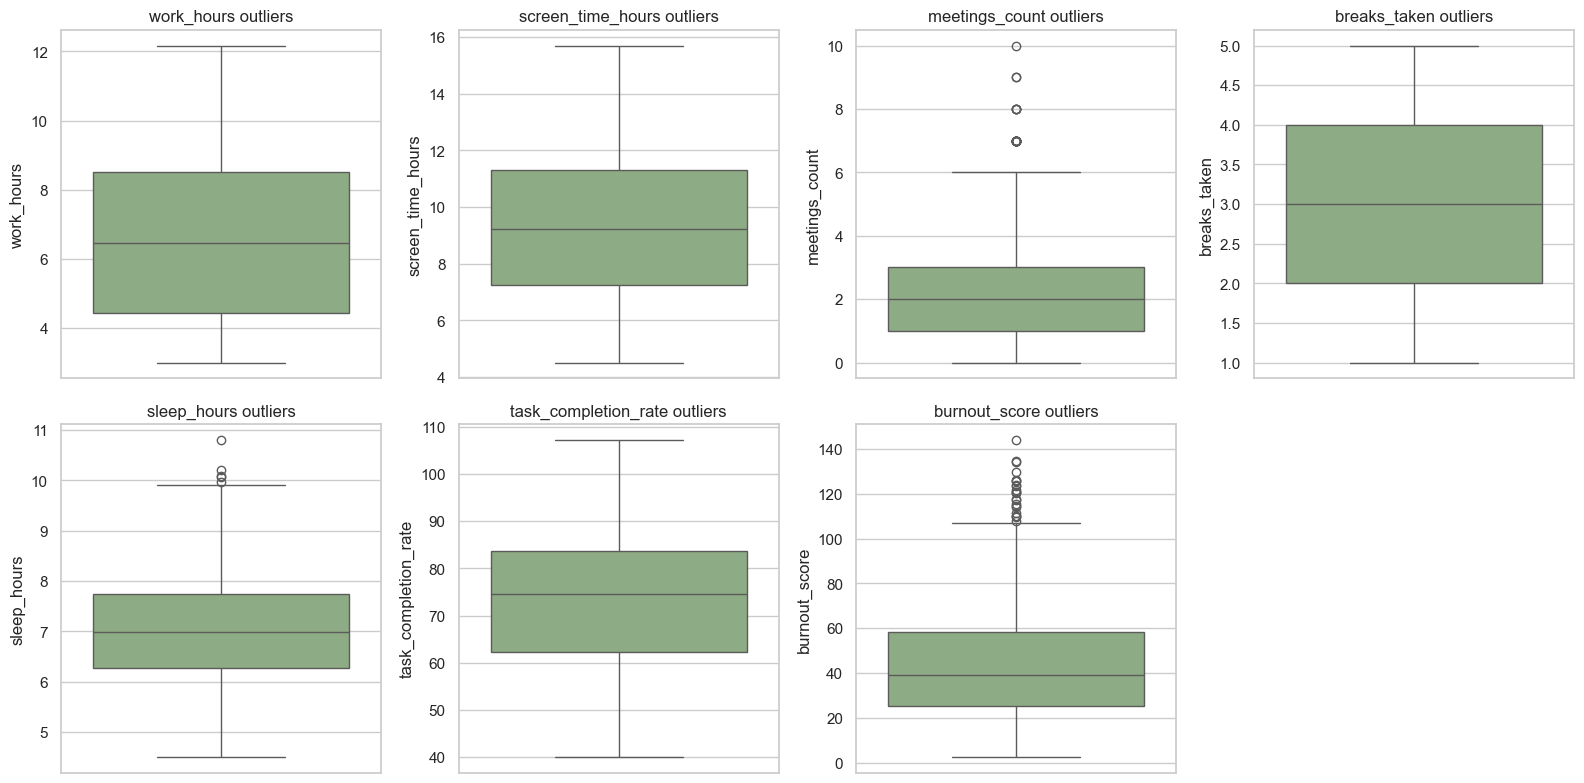

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for ax, col in zip(axes, outlier_columns):
    sns.boxplot(data=df, y=col, ax=ax, color='#8ab17d')
    ax.set_title(f'{col} outliers')
for ax in axes[len(outlier_columns):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### Outlier decision

The outlier analysis is used as a diagnostic step, not as an automatic deletion rule. Removing high burnout values would make the model less useful for the most relevant cases. Therefore, all valid observations are retained.


## 4. Data Preparation

The preparation step uses `Pipeline` and `ColumnTransformer` to avoid data leakage: encoders and scalers are fitted only on the training data.


In [13]:
model_df = df.copy()

# Feature engineering interpretabile.
model_df['work_intensity'] = model_df['work_hours'] / model_df['breaks_taken'].clip(lower=1)
model_df['screen_work_ratio'] = model_df['screen_time_hours'] / model_df['work_hours'].clip(lower=0.1)
model_df['meeting_density'] = model_df['meetings_count'] / model_df['work_hours'].clip(lower=0.1)
model_df['sleep_deficit'] = (7 - model_df['sleep_hours']).clip(lower=0)
model_df['overwork_flag'] = (model_df['work_hours'] > 8).astype(int)

regression_target = 'burnout_score'
classification_target = 'burnout_risk'
group_col = 'user_id'

excluded_cols = [group_col, regression_target, classification_target]
feature_columns = [c for c in model_df.columns if c not in excluded_cols]

X = model_df[feature_columns]
y_reg = model_df[regression_target]
y_clf = model_df[classification_target]
groups = model_df[group_col]

categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

print('Feature columns:', feature_columns)
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)


Feature columns: ['day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate', 'work_intensity', 'screen_work_ratio', 'meeting_density', 'sleep_deficit', 'overwork_flag']
Numeric features: ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate', 'work_intensity', 'screen_work_ratio', 'meeting_density', 'sleep_deficit', 'overwork_flag']
Categorical features: ['day_type']


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    remainder='drop',
)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y_reg, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_reg_train, y_reg_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
y_clf_train, y_clf_test = y_clf.iloc[train_idx], y_clf.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print('Train rows:', len(X_train), 'Test rows:', len(X_test))
print('Train users:', groups_train.nunique(), 'Test users:', groups_test.nunique())
print('Users overlap:', len(set(groups_train) & set(groups_test)))
print('\nTrain class distribution:')
print(y_clf_train.value_counts())
print('\nTest class distribution:')
print(y_clf_test.value_counts())


Train rows: 1440 Test rows: 360
Train users: 144 Test users: 36
Users overlap: 0

Train class distribution:
burnout_risk
Low       1233
Medium     191
High        16
Name: count, dtype: int64

Test class distribution:
burnout_risk
Low       294
Medium     62
High        4
Name: count, dtype: int64


## 5. Modeling - Regression


In [15]:
def evaluate_regression(name, estimator, X_train, y_train, X_test, y_test):
    estimator.fit(X_train, y_train)
    train_pred = estimator.predict(X_train)
    test_pred = estimator.predict(X_test)
    return {
        'model': name,
        'train_MAE': mean_absolute_error(y_train, train_pred),
        'test_MAE': mean_absolute_error(y_test, test_pred),
        'test_RMSE': root_mean_squared_error(y_test, test_pred),
        'test_R2': r2_score(y_test, test_pred),
        'estimator': estimator,
        'test_predictions': test_pred,
    }

regression_models = {
    'Dummy median': DummyRegressor(strategy='median'),
    'Ridge': Pipeline([('preprocess', preprocessor), ('model', Ridge(alpha=1.0))]),
    'KNN': Pipeline([('preprocess', preprocessor), ('model', KNeighborsRegressor(n_neighbors=15))]),
    'Random Forest': Pipeline([('preprocess', preprocessor), ('model', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=3))]),
    'Hist Gradient Boosting': Pipeline([('preprocess', preprocessor), ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE, max_iter=200, learning_rate=0.05))]),
}

regression_results = []
for name, estimator in regression_models.items():
    if name == 'Dummy median':
        result = evaluate_regression(name, estimator, X_train, y_reg_train, X_test, y_reg_test)
    else:
        result = evaluate_regression(name, estimator, X_train, y_reg_train, X_test, y_reg_test)
    regression_results.append(result)

regression_table = pd.DataFrame(regression_results).drop(columns=['estimator', 'test_predictions']).sort_values('test_MAE')
regression_table


,model,train_MAE,test_MAE,test_RMSE,test_R2
1,Ridge,5.004258,4.793076,6.309660,0.934267
3,Random Forest,2.607451,4.853357,6.414064,0.932073
4,Hist Gradient Boosting,2.510974,5.142693,6.730326,0.925210
2,KNN,8.129104,9.264493,11.650910,0.775873
0,Dummy median,18.447215,20.348972,25.797825,-0.098855


In [16]:
cv = GroupKFold(n_splits=5)
cv_rows = []
for name, estimator in regression_models.items():
    scores = cross_validate(
        estimator,
        X_train,
        y_reg_train,
        groups=groups_train,
        cv=cv,
        scoring={'MAE': 'neg_mean_absolute_error', 'R2': 'r2'},
        n_jobs=-1,
    )
    cv_rows.append({
        'model': name,
        'cv_MAE_mean': -scores['test_MAE'].mean(),
        'cv_MAE_std': scores['test_MAE'].std(),
        'cv_R2_mean': scores['test_R2'].mean(),
    })

cv_regression_table = pd.DataFrame(cv_rows).sort_values('cv_MAE_mean')
cv_regression_table


,model,cv_MAE_mean,cv_MAE_std,cv_R2_mean
3,Random Forest,4.969923,0.264099,0.922843
1,Ridge,5.064411,0.247102,0.916054
4,Hist Gradient Boosting,5.185601,0.298018,0.916735
2,KNN,9.032748,0.624583,0.743606
0,Dummy median,18.463071,1.327400,-0.046156


### 5.1 Hyperparameter Tuning

A light Random Forest tuning step is used. The goal is to improve a strong baseline without turning the project into blind AutoML.


In [17]:
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_distributions = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [None, 4, 6, 10],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 0.7, 1.0],
}

reg_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
reg_search.fit(X_train, y_reg_train, groups=groups_train)

best_reg_model = reg_search.best_estimator_
best_reg_pred = best_reg_model.predict(X_test)

print('Best params:', reg_search.best_params_)
print('CV MAE:', -reg_search.best_score_)
print('Test MAE:', mean_absolute_error(y_reg_test, best_reg_pred))
print('Test RMSE:', root_mean_squared_error(y_reg_test, best_reg_pred))
print('Test R2:', r2_score(y_reg_test, best_reg_pred))


Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 8, 'model__max_features': 1.0, 'model__max_depth': 4}
CV MAE: 4.846557154815978
Test MAE: 4.8793117736362746
Test RMSE: 6.214934490886778
Test R2: 0.936225479855046


## 6. Regression Evaluation and Interpretability


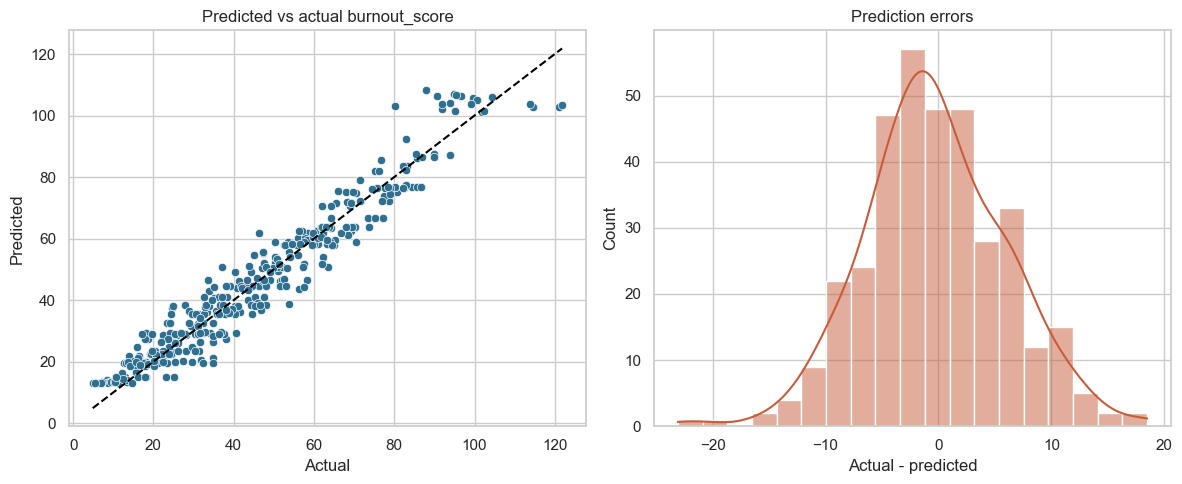

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=y_reg_test, y=best_reg_pred, ax=axes[0], color='#2f6f8f')
min_v = min(y_reg_test.min(), best_reg_pred.min())
max_v = max(y_reg_test.max(), best_reg_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], color='black', linestyle='--')
axes[0].set_title('Predicted vs actual burnout_score')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

errors = y_reg_test - best_reg_pred
sns.histplot(errors, kde=True, ax=axes[1], color='#c65d3a')
axes[1].set_title('Prediction errors')
axes[1].set_xlabel('Actual - predicted')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'regression_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
error_df = X_test.copy()
error_df['actual_score'] = y_reg_test.values
error_df['predicted_score'] = best_reg_pred
error_df['absolute_error'] = np.abs(error_df['actual_score'] - error_df['predicted_score'])
error_df['actual_risk'] = y_clf_test.values

display(error_df.groupby('actual_risk')['absolute_error'].agg(['count', 'mean', 'median', 'max']).loc[order])
display(error_df.sort_values('absolute_error', ascending=False).head(10))


,count,mean,median,max
actual_risk,,,,
Low,294,4.505169,3.688294,15.665295
Medium,62,6.023864,5.767268,23.076524
High,4,14.638234,15.029723,18.472872


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,work_intensity,screen_work_ratio,meeting_density,sleep_deficit,overwork_flag,actual_score,predicted_score,absolute_error,actual_risk
687,Weekday,8.86,12.56,1,2,0,7.43,40.0,4.4300,1.417607,0.112867,0.00,1,80.18,103.256524,23.076524,Medium
699,Weekday,9.02,10.90,2,5,0,9.27,40.0,1.8040,1.208426,0.221729,0.00,1,87.87,108.402510,20.532510,Medium
1139,Weekend,3.07,6.82,0,2,0,6.26,40.0,1.5350,2.221498,0.000000,0.74,0,121.82,103.347128,18.472872,High
1138,Weekday,7.33,10.23,1,4,0,6.49,40.0,1.8325,1.395634,0.136426,0.51,0,120.94,102.658803,18.281197,High
1135,Weekday,8.11,11.13,4,4,1,8.52,40.0,2.0275,1.372380,0.493218,0.00,1,90.57,106.262875,15.692875,Medium
93,Weekday,8.07,9.92,6,2,0,8.96,59.2,4.0350,1.229244,0.743494,0.00,1,46.19,61.855295,15.665295,Low
1597,Weekend,5.90,9.59,0,1,1,7.02,90.2,5.9000,1.625424,0.000000,0.00,0,34.90,19.516411,15.383589,Low
183,Weekday,10.07,11.93,1,4,1,6.76,73.7,2.5175,1.184707,0.099305,0.24,1,53.77,38.853951,14.916049,Low
961,Weekday,8.17,10.28,2,1,1,5.19,87.4,8.1700,1.258262,0.244798,1.81,1,34.86,21.219679,13.640321,Low
154,Weekday,8.48,11.67,3,2,1,5.82,66.6,4.2400,1.376179,0.353774,1.18,1,37.16,50.607373,13.447373,Low


,feature,importance_mean,importance_std
7,task_completion_rate,2.285971e+01,7.782986e-01
8,work_intensity,8.509307e-03,5.623078e-03
10,meeting_density,8.351627e-03,5.085376e-03
1,work_hours,5.309635e-03,1.990034e-03
2,screen_time_hours,4.049933e-03,2.888642e-03
4,breaks_taken,3.704377e-04,2.428670e-03
5,after_hours_work,6.624681e-05,6.887297e-04
0,day_type,5.329071e-16,5.178926e-16
12,overwork_flag,4.884981e-16,6.571920e-16
3,meetings_count,-7.892649e-05,9.902071e-04


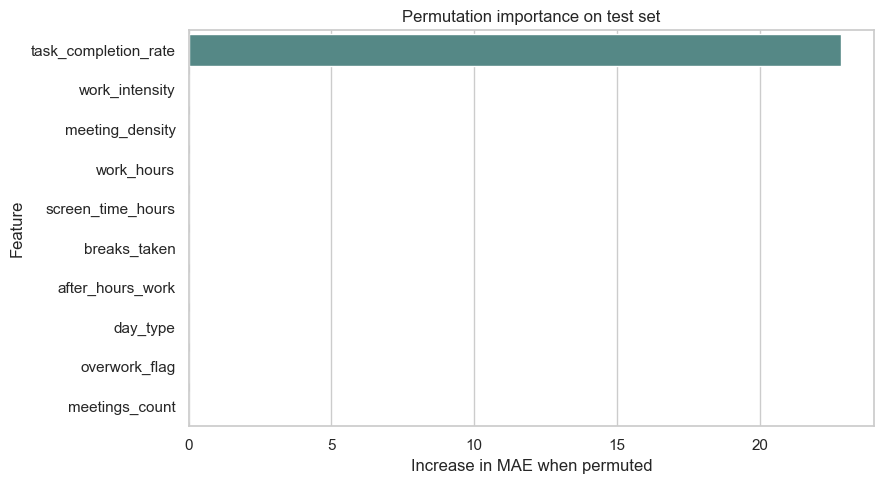

In [20]:
perm = permutation_importance(
    best_reg_model,
    X_test,
    y_reg_test,
    scoring='neg_mean_absolute_error',
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

display(importance)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance.head(10), x='importance_mean', y='feature', color='#4d908e')
plt.title('Permutation importance on test set')
plt.xlabel('Increase in MAE when permuted')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 6.1 Sensitivity Analysis Without `task_completion_rate`

`task_completion_rate` is extremely correlated with `burnout_score`. This makes it predictive, but also potentially problematic: it may be a direct proxy for the target or part of the synthetic target-generation logic. To make the project more robust, we repeat the regression experiment without this feature and compare performance.


In [21]:
sensitive_feature = 'task_completion_rate'
feature_columns_wo_completion = [c for c in feature_columns if c != sensitive_feature]

X_wo = model_df[feature_columns_wo_completion]
X_train_wo, X_test_wo = X_wo.iloc[train_idx], X_wo.iloc[test_idx]

categorical_features_wo = X_wo.select_dtypes(include='object').columns.tolist()
numeric_features_wo = [c for c in X_wo.columns if c not in categorical_features_wo]

preprocessor_wo_completion = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_wo),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_wo),
    ],
    remainder='drop',
)

sensitivity_models = {
    'Ridge without completion': Pipeline([
        ('preprocess', preprocessor_wo_completion),
        ('model', Ridge(alpha=1.0)),
    ]),
    'Random Forest without completion': Pipeline([
        ('preprocess', preprocessor_wo_completion),
        ('model', RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            min_samples_leaf=3,
        )),
    ]),
    'Hist Gradient Boosting without completion': Pipeline([
        ('preprocess', preprocessor_wo_completion),
        ('model', HistGradientBoostingRegressor(
            random_state=RANDOM_STATE,
            max_iter=200,
            learning_rate=0.05,
        )),
    ]),
}

sensitivity_rows = []
for name, estimator in sensitivity_models.items():
    estimator.fit(X_train_wo, y_reg_train)
    pred = estimator.predict(X_test_wo)
    sensitivity_rows.append({
        'model': name,
        'test_MAE': mean_absolute_error(y_reg_test, pred),
        'test_RMSE': root_mean_squared_error(y_reg_test, pred),
        'test_R2': r2_score(y_reg_test, pred),
    })

sensitivity_table = pd.DataFrame(sensitivity_rows).sort_values('test_MAE')
comparison_with_sensitive_feature = pd.concat([
    regression_table[['model', 'test_MAE', 'test_RMSE', 'test_R2']].assign(feature_set='all features'),
    sensitivity_table.assign(feature_set='without task_completion_rate'),
], ignore_index=True)

comparison_with_sensitive_feature.sort_values(['feature_set', 'test_MAE'])


,model,test_MAE,test_RMSE,test_R2,feature_set
0,Ridge,4.793076,6.309660,0.934267,all features
1,Random Forest,4.853357,6.414064,0.932073,all features
2,Hist Gradient Boosting,5.142693,6.730326,0.925210,all features
3,KNN,9.264493,11.650910,0.775873,all features
4,Dummy median,20.348972,25.797825,-0.098855,all features
5,Ridge without completion,20.245991,24.780140,-0.013868,without task_completion_rate
6,Random Forest without completion,20.261510,25.198899,-0.048425,without task_completion_rate
7,Hist Gradient Boosting without completion,21.127016,26.226989,-0.135719,without task_completion_rate


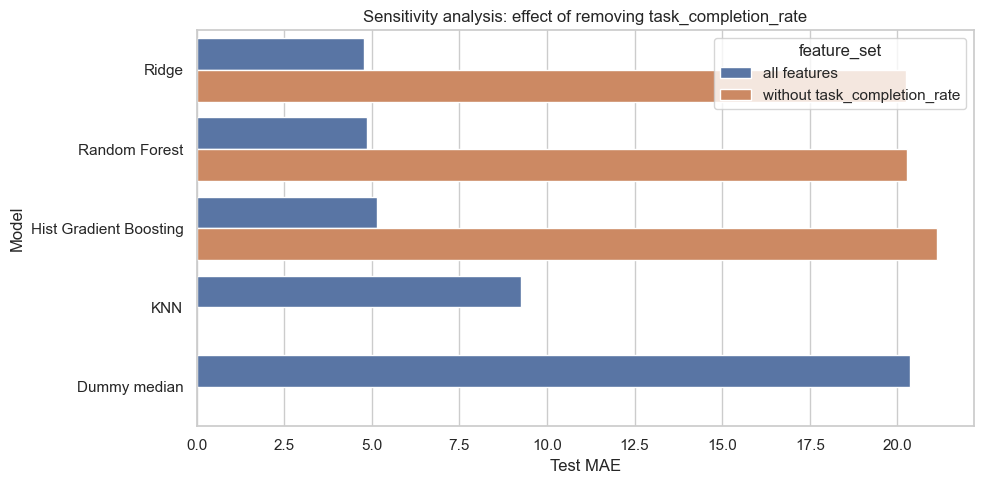

In [22]:
plt.figure(figsize=(10, 5))
plot_df = comparison_with_sensitive_feature.copy()
plot_df['model_short'] = plot_df['model'].str.replace(' without completion', '', regex=False)
sns.barplot(data=plot_df, x='test_MAE', y='model_short', hue='feature_set')
plt.title('Sensitivity analysis: effect of removing task_completion_rate')
plt.xlabel('Test MAE')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sensitivity_without_task_completion.png', dpi=150, bbox_inches='tight')
plt.show()


### Sensitivity interpretation

If performance drops substantially without `task_completion_rate`, the feature is carrying most of the predictive signal. This is not necessarily wrong, but it weakens causal interpretation and strengthens the need for external validation. The model should be presented as predictive, not diagnostic or causal.


## 7. Modeling - Classification Task

Classification is secondary because the `High` class is rare. The main metrics are macro F1, balanced accuracy and class-level recall.


In [23]:
def evaluate_classifier(name, estimator, X_train, y_train, X_test, y_test):
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_test)
    return {
        'model': name,
        'balanced_accuracy': balanced_accuracy_score(y_test, pred),
        'macro_f1': f1_score(y_test, pred, average='macro'),
        'estimator': estimator,
        'predictions': pred,
    }

classification_models = {
    'Dummy most frequent': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression balanced': Pipeline([
        ('preprocess', preprocessor),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'Random Forest balanced': Pipeline([
        ('preprocess', preprocessor),
        ('model', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2)),
    ]),
    'Hist Gradient Boosting': Pipeline([
        ('preprocess', preprocessor),
        ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=200, learning_rate=0.05)),
    ]),
}

classification_results = []
for name, estimator in classification_models.items():
    classification_results.append(evaluate_classifier(name, estimator, X_train, y_clf_train, X_test, y_clf_test))

classification_table = pd.DataFrame(classification_results).drop(columns=['estimator', 'predictions']).sort_values('macro_f1', ascending=False)
classification_table


,model,balanced_accuracy,macro_f1
1,Logistic Regression balanced,0.802593,0.645752
2,Random Forest balanced,0.632982,0.621661
3,Hist Gradient Boosting,0.613744,0.613289
0,Dummy most frequent,0.333333,0.299694


Best classifier: Logistic Regression balanced
              precision    recall  f1-score   support

         Low       0.99      0.93      0.96       294
      Medium       0.68      0.73      0.70        62
        High       0.17      0.75      0.27         4

    accuracy                           0.89       360
   macro avg       0.61      0.80      0.65       360
weighted avg       0.93      0.89      0.91       360



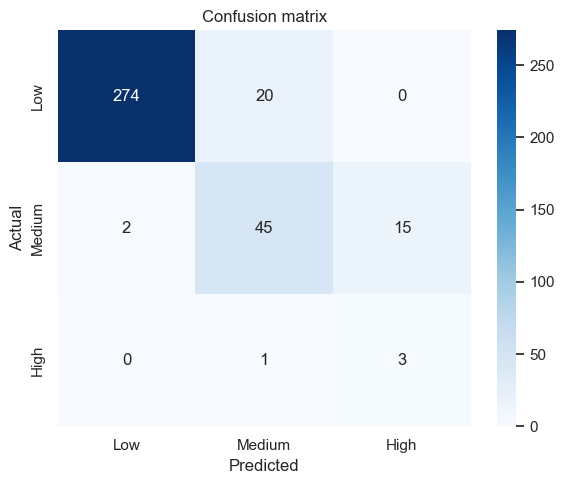

In [24]:
best_clf_row = max(classification_results, key=lambda row: row['macro_f1'])
best_clf_model = best_clf_row['estimator']
best_clf_pred = best_clf_row['predictions']

print('Best classifier:', best_clf_row['model'])
print(classification_report(y_clf_test, best_clf_pred, labels=order, zero_division=0))

cm = confusion_matrix(y_clf_test, best_clf_pred, labels=order)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=order, yticklabels=order)
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Fairness and Ethics Checks

The dataset does not contain classic sensitive attributes. We still check operational subgroups: `day_type`, `after_hours_work` and work-hour bands. These checks do not prove fairness, but they help detect differences in model error across groups.


In [25]:
fairness_df = X_test.copy()
fairness_df['actual_score'] = y_reg_test.values
fairness_df['predicted_score'] = best_reg_pred
fairness_df['absolute_error'] = np.abs(fairness_df['actual_score'] - fairness_df['predicted_score'])
fairness_df['actual_risk'] = y_clf_test.values
fairness_df['predicted_risk'] = best_clf_pred
fairness_df['work_hours_band'] = pd.cut(
    fairness_df['work_hours'],
    bins=[0, 6, 8, 24],
    labels=['short', 'standard', 'long'],
    include_lowest=True,
)

for group_col_name in ['day_type', 'after_hours_work', 'work_hours_band']:
    print('\nRegression absolute error by', group_col_name)
    display(fairness_df.groupby(group_col_name, observed=True)['absolute_error'].agg(['count', 'mean', 'median', 'max']))



Regression absolute error by day_type


,count,mean,median,max
day_type,,,,
Weekday,182,5.005918,3.678958,23.076524
Weekend,178,4.749860,4.412433,18.472872



Regression absolute error by after_hours_work


,count,mean,median,max
after_hours_work,,,,
0,225,5.193200,4.554689,23.076524
1,135,4.356165,3.243765,15.692875



Regression absolute error by work_hours_band


,count,mean,median,max
work_hours_band,,,,
short,158,4.838761,4.412433,18.472872
standard,69,4.468068,2.945494,18.281197
long,133,5.140837,3.906421,23.076524


In [26]:
# Equal-opportunity inspired check for the high-risk class: recall by subgroup.
def high_risk_recall_by_group(frame, group_col_name):
    rows = []
    for value, part in frame.groupby(group_col_name, observed=True):
        positives = part['actual_risk'].eq('High')
        if positives.sum() == 0:
            recall = np.nan
        else:
            recall = (part.loc[positives, 'predicted_risk'] == 'High').mean()
        rows.append({
            'group': value,
            'rows': len(part),
            'actual_high_cases': int(positives.sum()),
            'high_risk_recall': recall,
        })
    return pd.DataFrame(rows)

for group_col_name in ['day_type', 'after_hours_work', 'work_hours_band']:
    print('\nHigh-risk recall by', group_col_name)
    display(high_risk_recall_by_group(fairness_df, group_col_name))



High-risk recall by day_type


,group,rows,actual_high_cases,high_risk_recall
0,Weekday,182,3,1.0
1,Weekend,178,1,0.0



High-risk recall by after_hours_work


,group,rows,actual_high_cases,high_risk_recall
0,0,225,4,0.75
1,1,135,0,NaN



High-risk recall by work_hours_band


,group,rows,actual_high_cases,high_risk_recall
0,short,158,1,0.0
1,standard,69,1,1.0
2,long,133,2,1.0


## 9. Deployment Plan

A realistic deployment should be cautious:

1. Save the complete pipeline, not only the model.
2. Validate the model on external real-world data before operational use.
3. Use the output as aggregate decision support, not as an automatic individual decision.
4. Monitor feature drift and performance drift.
5. Repeat leakage, fairness and subgroup-performance audits.


In [27]:
model_path = MODELS_DIR / 'burnout_score_regression_pipeline.joblib'
joblib.dump(best_reg_model, model_path)
print(f'Saved model to {model_path}')


Saved model to models/burnout_score_regression_pipeline.joblib


## 10. Conclusions

The project follows CRISP-DM: it starts from the business problem, analyzes data quality and limitations, uses reproducible preprocessing, compares baselines and models, evaluates errors, interprets features and discusses fairness and deployment.

Regression on `burnout_score` is the most stable task. Classification on `burnout_risk` must be interpreted carefully because the `High` class is strongly imbalanced.

The main technical caveat is `task_completion_rate`: it is highly predictive, but it may be too close to the target-generation process. For this reason, the notebook includes a sensitivity analysis without this feature. The results show that the model should be interpreted as a predictive tool, not as evidence of causal burnout mechanisms. This distinction is important for transparent reporting and responsible use.

Before any real-world use, the model would need external validation, feature review, fairness governance and human oversight.
